# Proyecto Resultados – Modelos de clasificación

Notebook unificado con los tres algoritmos evaluados:
Random Forest, XGBoost (Gradient Boosting) y Regresión Logística.

Las secciones 1-7 (carga, limpieza, variable respuesta, predictoras, split, preprocesamiento) son compartidas por los tres algoritmos. A partir de la sección 8 cada algoritmo tiene su propio bloque independiente de entrenamiento, selección de modelo y resultados. La sección final compara los tres.

## 1. Carga de librerías

In [21]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
    print("XGBoost disponible.")
except ImportError:
    raise ImportError("XGBoost no instalado. Ejecutar: pip install xgboost")

RANDOM_STATE = 42
ORDEN_CLASES = ["temprana", "intermedia", "tardia"]

os.makedirs("outputs", exist_ok=True)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

XGBoost disponible.


## 2. Carga de datos

In [22]:
def cargar_datos():
    ruta_sav = "base_final_unificada_normalizada.sav"

    if os.path.exists(ruta_sav):
        try:
            df = pd.read_spss(ruta_sav)
            print(f"Base cargada desde: {ruta_sav}")
            return df
        except Exception as e:
            print("No se pudo leer el archivo .sav.")
            print("Detalle:", e)
            print("Probablemente falta instalar pyreadstat. Probá ejecutar:")
            print("pip install pyreadstat")
            print("Se intentará cargar archivos .xlsx como respaldo.\n")

    archivos_xlsx = sorted(glob.glob("divorcios*.xlsx"))
    if len(archivos_xlsx) > 0:
        lista = []
        for archivo in archivos_xlsx:
            temp = pd.read_excel(archivo)
            temp = temp.rename(columns={"PPERHOM": "PUEHOM", "PPERMUJ": "PUEMUJ"})
            temp["ARCHIVO_ORIGEN"] = os.path.basename(archivo)
            lista.append(temp)
        df = pd.concat(lista, ignore_index=True)
        print(f"Base cargada desde {len(archivos_xlsx)} archivos xlsx.")
        return df

    raise FileNotFoundError(
        "No se encontró base_final_unificada_normalizada.sav ni archivos divorcios*.xlsx. "
        "Colocá la base en la misma carpeta del notebook."
    )

df = cargar_datos()
print("Dimensiones de la base:", df.shape)
display(df.head())
display(df.dtypes.to_frame("tipo_dato").T)

Base cargada desde: base_final_unificada_normalizada.sav
Dimensiones de la base: (71576, 23)


,DEPREG,MUPREG,MESREG,AÑOREG,DIAOCU,MESOCU,AÑOOCU,DEPOCU,MUPOCU,EDADHOM,EDADMUJ,PUEHOM,PUEMUJ,NACHOM,NACMUJ,ESCHOM,ESCMUJ,CIUOHOM,CIUOMUJ,GETHOM,GETMUJ,OCUHOM,OCUMUJ
0,Guatemala,Guatemala,Diciembre,2016.0000,3.0000,Noviembre,2016.0000,Guatemala,Guatemala,Ignorado,Ignorado,Ignorado,Ignorado,Argentina,Guatemala,Ignorado,Ignorado,No especificado en otro grupo,Profesionales de la enseñanza,,,,
1,Guatemala,Guatemala,Agosto,2016.0000,17.0000,Mayo,2016.0000,Guatemala,Guatemala,58.0,Ignorado,Ignorado,Ignorado,Argentina,Guatemala,Ignorado,Ignorado,No especificado en otro grupo,No especificado en otro grupo,,,,
2,Peten,Flores,Agosto,2016.0000,11.0000,Agosto,2016.0000,Guatemala,Guatemala,61.0,53.0,Ignorado,Ignorado,Argentina,Guatemala,Ninguno,Ninguno,Ignorado,Ignorado,,,,
3,Guatemala,Guatemala,Marzo,2017.0000,7.0000,Octubre,2016.0000,Guatemala,Guatemala,39.0,38.0,Ignorado,Mestizo / Ladino,Austria,Guatemala,Ignorado,Universitario,Vendedores,"Profesionales en derecho, en ciencias sociales...",,,,
4,Zacapa,Teculután,Febrero,2017.0000,23.0000,Noviembre,2016.0000,El Progreso,Sanarate,Ignorado,Ignorado,Ignorado,Ignorado,Chile,Guatemala,Ignorado,Ignorado,"Oficiales y operarios de la metalurgia, la con...",No especificado en otro grupo,,,,


,DEPREG,MUPREG,MESREG,AÑOREG,DIAOCU,MESOCU,AÑOOCU,DEPOCU,MUPOCU,EDADHOM,EDADMUJ,PUEHOM,PUEMUJ,NACHOM,NACMUJ,ESCHOM,ESCMUJ,CIUOHOM,CIUOMUJ,GETHOM,GETMUJ,OCUHOM,OCUMUJ
tipo_dato,str,str,str,float64,float64,str,float64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str


## 3. Limpieza mínima de edades

In [23]:
df_modelo = df.copy()

for col in ["EDADHOM", "EDADMUJ"]:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors="coerce")

df_modelo.loc[(df_modelo["EDADHOM"] < 15) | (df_modelo["EDADHOM"] > 100), "EDADHOM"] = np.nan
df_modelo.loc[(df_modelo["EDADMUJ"] < 15) | (df_modelo["EDADMUJ"] > 100), "EDADMUJ"] = np.nan

antes = len(df_modelo)
df_modelo = df_modelo.dropna(subset=["EDADHOM", "EDADMUJ"]).copy()
despues = len(df_modelo)

print(f"Registros antes de limpiar edades: {antes:,}")
print(f"Registros después de limpiar edades: {despues:,}")
print(f"Registros eliminados: {antes - despues:,}")

df_modelo[["EDADHOM", "EDADMUJ"]].describe()

Registros antes de limpiar edades: 71,576
Registros después de limpiar edades: 34,359
Registros eliminados: 37,217


,EDADHOM,EDADMUJ
count,34359.0000,34359.0000
mean,35.4729,32.3101
std,9.7657,8.8623
min,15.0000,15.0000
25%,29.0000,26.0000
50%,33.0000,31.0000
75%,40.0000,37.0000
max,98.0000,81.0000


## 4. Variable respuesta

Puntos de corte usados para la variable respuesta:
Corte 0: 17.00
Corte 1: 29.00
Corte 2: 35.50
Corte 3: 81.50


,frecuencia,porcentaje
ETAPA_VIDA_PAREJA,,
temprana,11819,34.4000
intermedia,11091,32.2800
tardia,11449,33.3200


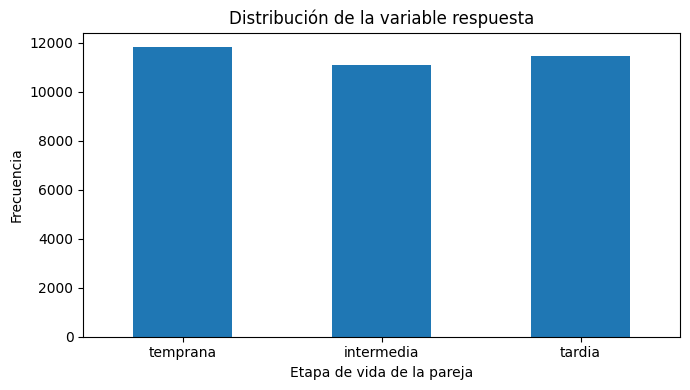

In [24]:
df_modelo["EDAD_PROMEDIO_PAREJA"] = (
    df_modelo["EDADHOM"] + df_modelo["EDADMUJ"]
) / 2

df_modelo["ETAPA_VIDA_PAREJA"], cortes = pd.qcut(
    df_modelo["EDAD_PROMEDIO_PAREJA"],
    q=3,
    labels=["temprana", "intermedia", "tardia"],
    retbins=True,
    duplicates="drop"
)

print("Puntos de corte usados para la variable respuesta:")
for i, corte in enumerate(cortes):
    print(f"Corte {i}: {corte:.2f}")

tabla_respuesta = (
    df_modelo["ETAPA_VIDA_PAREJA"]
    .value_counts()
    .sort_index()
    .to_frame("frecuencia")
)
tabla_respuesta["porcentaje"] = (tabla_respuesta["frecuencia"] / len(df_modelo) * 100).round(2)

display(tabla_respuesta)

plt.figure(figsize=(7, 4))
tabla_respuesta["frecuencia"].plot(kind="bar")
plt.title("Distribución de la variable respuesta")
plt.xlabel("Etapa de vida de la pareja")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/grafico1_distribucion_variable_respuesta.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Variables predictoras

In [25]:
target = "ETAPA_VIDA_PAREJA"

columnas_no_predictoras = [
    target,
    "EDAD_PROMEDIO_PAREJA",
    "EDADHOM",
    "EDADMUJ"
]

X = df_modelo.drop(columns=[c for c in columnas_no_predictoras if c in df_modelo.columns])
y = df_modelo[target].astype(str)

cat_cols_posibles = [
    "DEPREG", "MUPREG", "MESREG",
    "MESOCU", "DEPOCU", "MUPOCU",
    "PUEHOM", "PUEMUJ", "PPERHOM", "PPERMUJ",
    "NACHOM", "NACMUJ",
    "ESCHOM", "ESCMUJ",
    "CIUOHOM", "CIUOMUJ",
    "GETHOM", "GETMUJ",
    "OCUHOM", "OCUMUJ",
    "CLAUNI", "NUNUHO", "NUNUMU",
    "ARCHIVO_ORIGEN"
]

num_cols_posibles = ["DIAOCU", "AÑOOCU", "AÑOREG"]

cat_cols = [c for c in cat_cols_posibles if c in X.columns]
num_cols = [c for c in num_cols_posibles if c in X.columns]

otras = [c for c in X.columns if c not in cat_cols + num_cols]
for c in otras:
    if pd.api.types.is_numeric_dtype(X[c]):
        num_cols.append(c)
    else:
        cat_cols.append(c)

for c in cat_cols:
    X[c] = X[c].astype("object").where(X[c].notna(), np.nan)

print("Cantidad de variables predictoras:", X.shape[1])
print("Columnas numéricas:", num_cols)
print("Columnas categóricas:", cat_cols)

Cantidad de variables predictoras: 21
Columnas numéricas: ['DIAOCU', 'AÑOOCU', 'AÑOREG']
Columnas categóricas: ['DEPREG', 'MUPREG', 'MESREG', 'MESOCU', 'DEPOCU', 'MUPOCU', 'PUEHOM', 'PUEMUJ', 'NACHOM', 'NACMUJ', 'ESCHOM', 'ESCMUJ', 'CIUOHOM', 'CIUOMUJ', 'GETHOM', 'GETMUJ', 'OCUHOM', 'OCUMUJ']


## 6. Conjuntos de entrenamiento y prueba

Registros de entrenamiento: 24,051 (70.00%)
Registros de prueba: 10,308 (30.00%)


,total,train,test
ETAPA_VIDA_PAREJA,,,
intermedia,32.2800,32.2800,32.2800
tardia,33.3200,33.3200,33.3200
temprana,34.4000,34.4000,34.4000


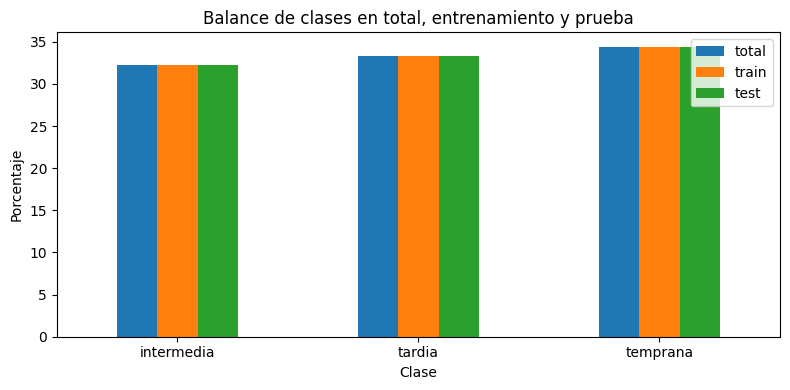

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Registros de entrenamiento: {len(X_train):,} ({len(X_train)/len(X)*100:.2f}%)")
print(f"Registros de prueba: {len(X_test):,} ({len(X_test)/len(X)*100:.2f}%)")

balance_total = y.value_counts(normalize=True).sort_index().rename("total")
balance_train = y_train.value_counts(normalize=True).sort_index().rename("train")
balance_test  = y_test.value_counts(normalize=True).sort_index().rename("test")

balance = pd.concat([balance_total, balance_train, balance_test], axis=1) * 100
balance = balance.round(2)
display(balance)

balance.plot(kind="bar", figsize=(8, 4))
plt.title("Balance de clases en total, entrenamiento y prueba")
plt.xlabel("Clase")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/grafico2_balance_train_test.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Preprocesamiento

Se aplica el mismo pipeline para los tres algoritmos:
- Variables **numéricas**: imputación por mediana.
- Variables **categóricas**: imputación por moda + One-Hot Encoding.

In [27]:
def crear_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", crear_onehot())
])

def nuevo_preprocesamiento():
    """Crea una instancia fresca del ColumnTransformer para cada algoritmo."""
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="drop"
    )

print("Pipeline de preprocesamiento definido.")

Pipeline de preprocesamiento definido.


### Función auxiliar de evaluación

Se centraliza el cálculo de métricas para no repetir código en cada algoritmo.

In [28]:
def evaluar_modelo(nombre, pipeline, X_tr, y_tr, X_te, y_te):
    """Entrena el pipeline y devuelve dict con métricas."""
    pipeline.fit(X_tr, y_tr)
    pred_train = pipeline.predict(X_tr)
    pred_test  = pipeline.predict(X_te)
    f1_tr  = f1_score(y_tr, pred_train, average="macro")
    f1_te  = f1_score(y_te, pred_test,  average="macro")
    return {
        "modelo": nombre,
        "accuracy_train":          round(accuracy_score(y_tr, pred_train), 4),
        "accuracy_test":           round(accuracy_score(y_te, pred_test),  4),
        "balanced_accuracy_test":  round(balanced_accuracy_score(y_te, pred_test), 4),
        "f1_macro_train":          round(f1_tr, 4),
        "f1_macro_test":           round(f1_te, 4),
        "gap_f1_train_test":       round(f1_tr - f1_te, 4),
        "_pred_test":              pred_test,
        "_pipeline":               pipeline
    }

def seleccionar_mejor(resultados_df, modelos_dict):
    """Elige el modelo con mejor f1_macro_test cuyo gap <= 0.10."""
    candidatos = resultados_df[resultados_df["gap_f1_train_test"] <= 0.10]
    pool = candidatos if len(candidatos) > 0 else resultados_df
    mejor = pool.sort_values(["f1_macro_test", "gap_f1_train_test"],
                              ascending=[False, True]).iloc[0]
    nombre = mejor["modelo"]
    return nombre, modelos_dict[nombre]["_pipeline"], modelos_dict[nombre]["_pred_test"]

def mostrar_resultados(nombre_algoritmo, mejor_nombre, y_te, y_pred, resultados_df, prefijo):
    """Imprime tabla de modelos, gráfico de comparación, matriz de confusión y reporte."""
    clases = [c for c in ORDEN_CLASES if c in y_te.unique()]

    # Tabla resumen
    cols_mostrar = [c for c in resultados_df.columns if not c.startswith("_")]
    display(resultados_df[cols_mostrar])
    resultados_df[cols_mostrar].to_csv(f"outputs/resumen_{prefijo}.csv", index=False)

    # Gráfico comparación F1
    plt.figure(figsize=(9, 4))
    plt.plot(resultados_df["modelo"], resultados_df["f1_macro_train"], marker="o", label="F1 macro train")
    plt.plot(resultados_df["modelo"], resultados_df["f1_macro_test"],  marker="o", label="F1 macro test")
    plt.title(f"Comparación de modelos – {nombre_algoritmo}")
    plt.xlabel("Modelo")
    plt.ylabel("F1 macro")
    plt.xticks(rotation=20)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"outputs/grafico_{prefijo}_comparacion.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Modelo final seleccionado
    fila_mejor = resultados_df[resultados_df["modelo"] == mejor_nombre].iloc[0]
    print(f"\nModelo final seleccionado: {mejor_nombre}")
    display(fila_mejor[[c for c in fila_mejor.index if not c.startswith("_")]].to_frame("valor"))

    # Matriz de confusión
    mat = confusion_matrix(y_te, y_pred, labels=clases)
    viz = ConfusionMatrixDisplay(confusion_matrix=mat, display_labels=clases)
    viz.plot(values_format="d")
    plt.title(f"Matriz de confusión – {mejor_nombre}")
    plt.tight_layout()
    plt.savefig(f"outputs/grafico_{prefijo}_confusion.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Guardar matriz CSV
    filas_idx = [f"Real_{c}" for c in clases]
    cols_idx  = [f"Pred_{c}" for c in clases]
    pd.DataFrame(mat, index=filas_idx, columns=cols_idx).to_csv(
        f"outputs/matriz_confusion_{prefijo}.csv")

    # Reporte
    print(f"\nReporte de clasificación – {nombre_algoritmo}:")
    print(classification_report(y_te, y_pred, labels=clases))

---
## 8. Algoritmo 1: Random Forest

### 8.1. Entrenamiento de modelos Random Forest

In [29]:
parametros_rf = [
    {"nombre": "RF_1_simple",       "n_estimators": 120, "max_depth": 8,    "min_samples_leaf": 30, "max_features": "sqrt"},
    {"nombre": "RF_2_intermedio",   "n_estimators": 180, "max_depth": 15,   "min_samples_leaf": 15, "max_features": "sqrt"},
    {"nombre": "RF_3_mas_flexible", "n_estimators": 220, "max_depth": None, "min_samples_leaf": 8,  "max_features": "sqrt"},
]

modelos_rf  = {}
resultados_rf_lista = []

for p in parametros_rf:
    nombre = p["nombre"]
    print(f"Entrenando {nombre}...")
    rf = RandomForestClassifier(
        n_estimators=p["n_estimators"],
        max_depth=p["max_depth"],
        min_samples_leaf=p["min_samples_leaf"],
        max_features=p["max_features"],
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    pipeline_rf = Pipeline([("preprocesamiento", nuevo_preprocesamiento()), ("modelo", rf)])
    res = evaluar_modelo(nombre, pipeline_rf, X_train, y_train, X_test, y_test)
    res.update({"n_estimators": p["n_estimators"], "max_depth": str(p["max_depth"]),
                "min_samples_leaf": p["min_samples_leaf"], "max_features": p["max_features"]})
    resultados_rf_lista.append(res)
    modelos_rf[nombre] = res

resultados_rf_df = pd.DataFrame(resultados_rf_lista).sort_values(
    ["f1_macro_test", "gap_f1_train_test"], ascending=[False, True]
)

Entrenando RF_1_simple...
Entrenando RF_2_intermedio...
Entrenando RF_3_mas_flexible...


### 8.2. Comparación de modelos y selección del mejor

,modelo,accuracy_train,accuracy_test,balanced_accuracy_test,f1_macro_train,f1_macro_test,gap_f1_train_test,n_estimators,max_depth,min_samples_leaf,max_features
2,RF_3_mas_flexible,0.5905,0.5147,0.5112,0.5816,0.5025,0.0792,220,None,8,sqrt
1,RF_2_intermedio,0.5362,0.5045,0.5004,0.5232,0.4895,0.0338,180,15,15,sqrt
0,RF_1_simple,0.5061,0.4977,0.4933,0.4897,0.4802,0.0095,120,8,30,sqrt


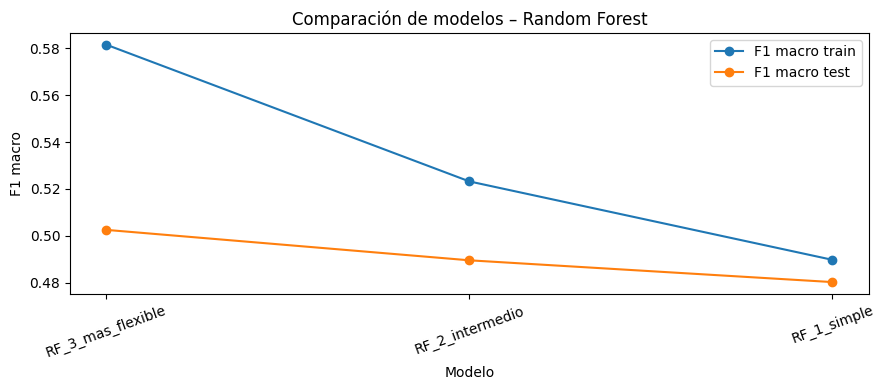


Modelo final seleccionado: RF_3_mas_flexible


,valor
modelo,RF_3_mas_flexible
accuracy_train,0.5905
accuracy_test,0.5147
balanced_accuracy_test,0.5112
f1_macro_train,0.5816
f1_macro_test,0.5025
gap_f1_train_test,0.0792
n_estimators,220
max_depth,None
min_samples_leaf,8


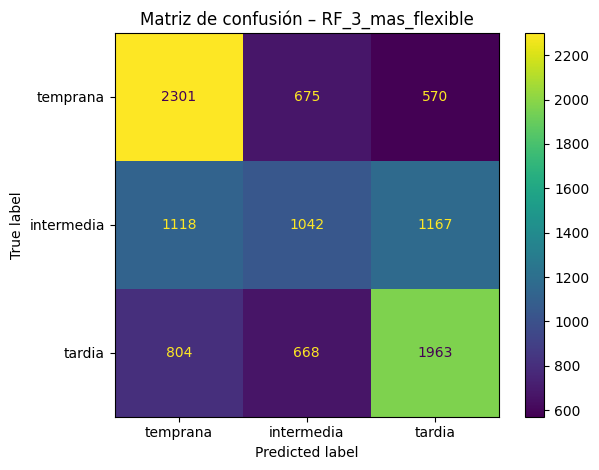


Reporte de clasificación – Random Forest:
              precision    recall  f1-score   support

    temprana       0.54      0.65      0.59      3546
  intermedia       0.44      0.31      0.36      3327
      tardia       0.53      0.57      0.55      3435

    accuracy                           0.51     10308
   macro avg       0.50      0.51      0.50     10308
weighted avg       0.51      0.51      0.50     10308



In [30]:
mejor_rf_nombre, modelo_rf_final, y_pred_rf = seleccionar_mejor(resultados_rf_df, modelos_rf)
mostrar_resultados("Random Forest", mejor_rf_nombre, y_test, y_pred_rf, resultados_rf_df, "rf")

### 8.3. Importancia de variables – Random Forest

,variable_original,importancia
8,ESCMUJ,0.1396
7,ESCHOM,0.1281
2,CIUOHOM,0.1118
3,CIUOMUJ,0.1013
19,PUEHOM,0.0649
20,PUEMUJ,0.0601
4,DEPOCU,0.0517
5,DEPREG,0.0489
1,AÑOREG,0.0466
13,MUPOCU,0.0459


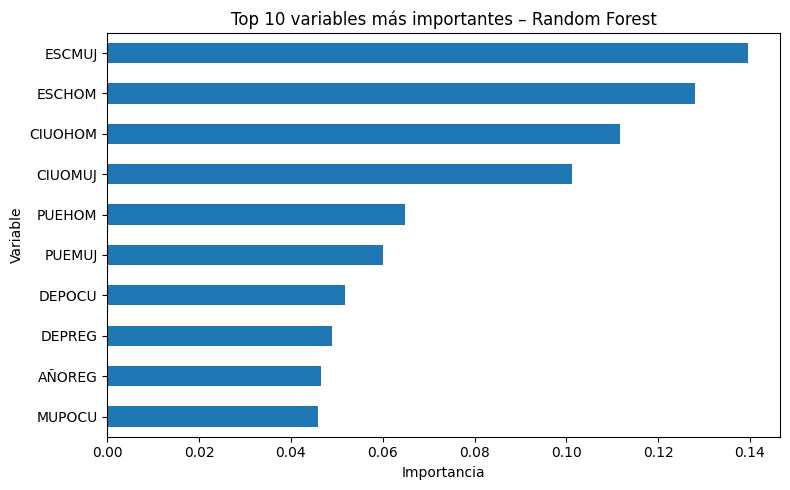

In [31]:
arbol_rf      = modelo_rf_final.named_steps["modelo"]
prep_rf_fit   = modelo_rf_final.named_steps["preprocesamiento"]

pesos_rf    = arbol_rf.feature_importances_
nombres_rf  = []
vars_rf     = []

for col in num_cols:
    nombres_rf.append(col)
    vars_rf.append(col)

enc_ohe_rf = prep_rf_fit.named_transformers_["cat"].named_steps["onehot"]
for col, categorias in zip(cat_cols, enc_ohe_rf.categories_):
    for cat in categorias:
        nombres_rf.append(f"{col}_{cat}")
        vars_rf.append(col)

n = min(len(pesos_rf), len(nombres_rf))
df_imp_rf = pd.DataFrame({"feature": nombres_rf[:n], "var_orig": vars_rf[:n], "peso": pesos_rf[:n]})

resumen_rf = (
    df_imp_rf.groupby("var_orig", as_index=False)["peso"].sum()
    .sort_values("peso", ascending=False)
    .rename(columns={"var_orig": "variable_original", "peso": "importancia"})
)

display(resumen_rf.head(15))
resumen_rf.to_csv("outputs/importancia_variables_rf.csv", index=False)

resumen_rf.head(10).sort_values("importancia").plot(
    kind="barh", x="variable_original", y="importancia", figsize=(8, 5), legend=False
)
plt.title("Top 10 variables más importantes – Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("outputs/grafico_rf_importancia.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 9. Algoritmo 2: XGBoost (Gradient Boosting)

### 9.1. Codificación de etiquetas para XGBoost

In [32]:
label_map     = {c: i for i, c in enumerate(ORDEN_CLASES)}
label_map_inv = {i: c for c, i in label_map.items()}

y_train_enc = y_train.map(label_map)
y_test_enc  = y_test.map(label_map)

# Preprocesar X una sola vez para XGBoost
prep_xgb = nuevo_preprocesamiento()
X_train_xgb = prep_xgb.fit_transform(X_train)
X_test_xgb  = prep_xgb.transform(X_test)

print("Dimensiones X_train transformado:", X_train_xgb.shape)
print("Dimensiones X_test transformado: ", X_test_xgb.shape)

Dimensiones X_train transformado: (24051, 1128)
Dimensiones X_test transformado:  (10308, 1128)


### 9.2. Entrenamiento de modelos XGBoost

In [33]:
parametros_xgb = [
    {"nombre": "XGB_1_conservador", "n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8},
    {"nombre": "XGB_2_intermedio",  "n_estimators": 200, "max_depth": 5, "learning_rate": 0.10, "subsample": 0.8},
    {"nombre": "XGB_3_agresivo",    "n_estimators": 300, "max_depth": 7, "learning_rate": 0.15, "subsample": 1.0},
]

modelos_xgb_dict  = {}
resultados_xgb_lista = []

for p in parametros_xgb:
    nombre = p["nombre"]
    print(f"Entrenando {nombre}...")
    xgb = XGBClassifier(
        n_estimators=p["n_estimators"],
        max_depth=p["max_depth"],
        learning_rate=p["learning_rate"],
        subsample=p["subsample"],
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb.fit(X_train_xgb, y_train_enc)

    pred_train_enc = xgb.predict(X_train_xgb)
    pred_test_enc  = xgb.predict(X_test_xgb)
    pred_train_lbl = pd.Series(pred_train_enc).map(label_map_inv).values
    pred_test_lbl  = pd.Series(pred_test_enc).map(label_map_inv).values

    f1_tr = f1_score(y_train, pred_train_lbl, average="macro")
    f1_te = f1_score(y_test,  pred_test_lbl,  average="macro")
    res = {
        "modelo": nombre,
        "n_estimators": p["n_estimators"], "max_depth": p["max_depth"],
        "learning_rate": p["learning_rate"], "subsample": p["subsample"],
        "accuracy_train":         round(accuracy_score(y_train, pred_train_lbl), 4),
        "accuracy_test":          round(accuracy_score(y_test,  pred_test_lbl),  4),
        "balanced_accuracy_test": round(balanced_accuracy_score(y_test, pred_test_lbl), 4),
        "f1_macro_train":         round(f1_tr, 4),
        "f1_macro_test":          round(f1_te, 4),
        "gap_f1_train_test":      round(f1_tr - f1_te, 4),
        "_pred_test": pred_test_lbl, "_pipeline": xgb
    }
    resultados_xgb_lista.append(res)
    modelos_xgb_dict[nombre] = res

resultados_xgb_df = pd.DataFrame(resultados_xgb_lista).sort_values(
    ["f1_macro_test", "gap_f1_train_test"], ascending=[False, True]
)

Entrenando XGB_1_conservador...
Entrenando XGB_2_intermedio...
Entrenando XGB_3_agresivo...


### 9.3. Comparación de modelos y selección del mejor

,modelo,n_estimators,max_depth,learning_rate,subsample,accuracy_train,accuracy_test,balanced_accuracy_test,f1_macro_train,f1_macro_test,gap_f1_train_test
2,XGB_3_agresivo,300,7,0.1500,1.0000,0.6979,0.5129,0.5096,0.6924,0.5026,0.1898
1,XGB_2_intermedio,200,5,0.1000,0.8000,0.6014,0.5145,0.5108,0.5917,0.5013,0.0904
0,XGB_1_conservador,100,3,0.0500,0.8000,0.5179,0.5062,0.5019,0.4990,0.4861,0.0128


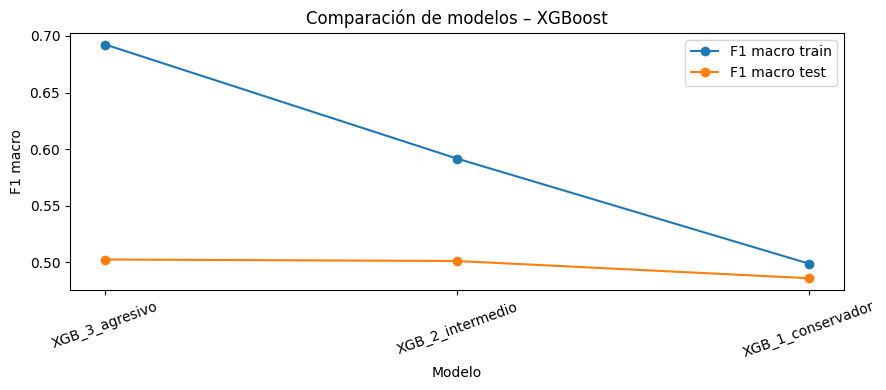


Modelo final seleccionado: XGB_2_intermedio


,valor
modelo,XGB_2_intermedio
n_estimators,200
max_depth,5
learning_rate,0.1000
subsample,0.8000
accuracy_train,0.6014
accuracy_test,0.5145
balanced_accuracy_test,0.5108
f1_macro_train,0.5917
f1_macro_test,0.5013


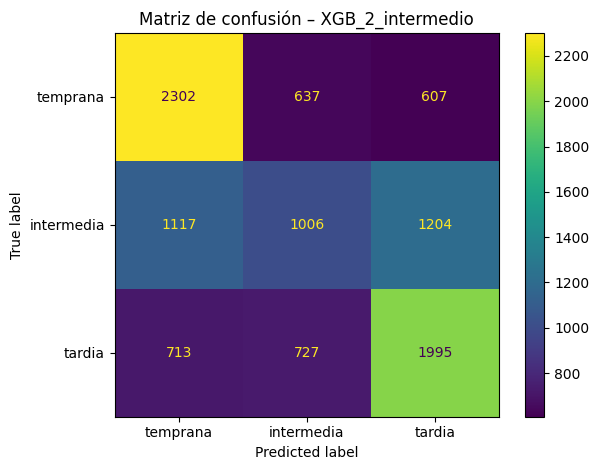


Reporte de clasificación – XGBoost:
              precision    recall  f1-score   support

    temprana       0.56      0.65      0.60      3546
  intermedia       0.42      0.30      0.35      3327
      tardia       0.52      0.58      0.55      3435

    accuracy                           0.51     10308
   macro avg       0.50      0.51      0.50     10308
weighted avg       0.50      0.51      0.50     10308



In [34]:
# Selección manual (sin usar la función helper porque XGBoost no usa Pipeline sklearn)
candidatos_xgb = resultados_xgb_df[resultados_xgb_df["gap_f1_train_test"] <= 0.10]
pool_xgb = candidatos_xgb if len(candidatos_xgb) > 0 else resultados_xgb_df
mejor_xgb_nombre = pool_xgb.sort_values(["f1_macro_test", "gap_f1_train_test"],
                                          ascending=[False, True]).iloc[0]["modelo"]
y_pred_xgb  = modelos_xgb_dict[mejor_xgb_nombre]["_pred_test"]

mostrar_resultados("XGBoost", mejor_xgb_nombre, y_test, y_pred_xgb, resultados_xgb_df, "xgb")

### 9.4. Importancia de variables – XGBoost

,variable_original,importancia
13,MUPOCU,0.3282
14,MUPREG,0.2513
2,CIUOHOM,0.0623
3,CIUOMUJ,0.0561
4,DEPOCU,0.0485
5,DEPREG,0.0440
8,ESCMUJ,0.0352
7,ESCHOM,0.0334
19,PUEHOM,0.0230
17,OCUHOM,0.0218


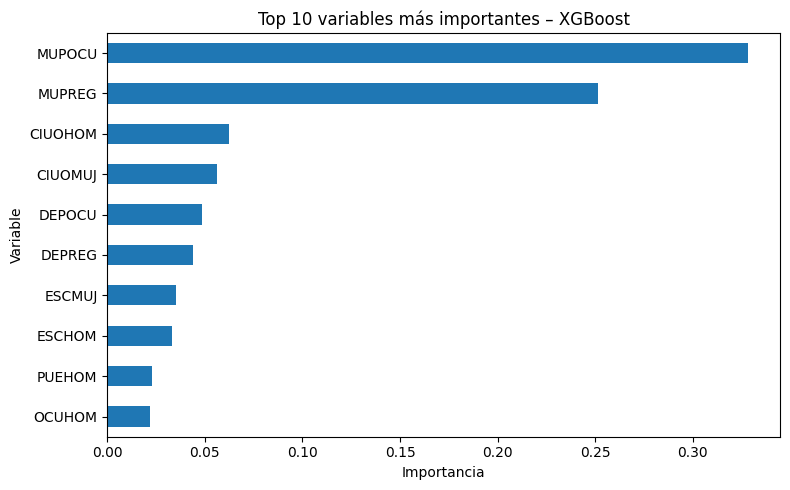

In [35]:
mejor_xgb_model = modelos_xgb_dict[mejor_xgb_nombre]["_pipeline"]
pesos_xgb = mejor_xgb_model.feature_importances_

nombres_xgb = []
vars_xgb    = []

enc_ohe_xgb = prep_xgb.named_transformers_["cat"].named_steps["onehot"]
for col in num_cols:
    nombres_xgb.append(col)
    vars_xgb.append(col)
for col, categorias in zip(cat_cols, enc_ohe_xgb.categories_):
    for cat in categorias:
        nombres_xgb.append(f"{col}_{cat}")
        vars_xgb.append(col)

n = min(len(pesos_xgb), len(nombres_xgb))
df_imp_xgb = pd.DataFrame({"feature": nombres_xgb[:n], "var_orig": vars_xgb[:n], "peso": pesos_xgb[:n]})

resumen_xgb = (
    df_imp_xgb.groupby("var_orig", as_index=False)["peso"].sum()
    .sort_values("peso", ascending=False)
    .rename(columns={"var_orig": "variable_original", "peso": "importancia"})
)

display(resumen_xgb.head(15))
resumen_xgb.to_csv("outputs/importancia_variables_xgb.csv", index=False)

resumen_xgb.head(10).sort_values("importancia").plot(
    kind="barh", x="variable_original", y="importancia", figsize=(8, 5), legend=False
)
plt.title("Top 10 variables más importantes – XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("outputs/grafico_xgb_importancia.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 10. Algoritmo 3: Regresión Logística

### 10.1. Entrenamiento de modelos de Regresión Logística

In [36]:
parametros_lr = [
    {"nombre": "LR_1_alta_regularizacion",  "C": 0.01, "max_iter": 500},
    {"nombre": "LR_2_regularizacion_media", "C": 0.1,  "max_iter": 1000},
    {"nombre": "LR_3_baja_regularizacion",  "C": 1.0,  "max_iter": 2000},
]

modelos_lr_dict = {}
resultados_lr_lista = []

for p in parametros_lr:
    nombre = p["nombre"]
    print(f"Entrenando {nombre}...")
    lr = LogisticRegression(
        C=p["C"],
        max_iter=p["max_iter"],
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    pipeline_lr = Pipeline([("preprocesamiento", nuevo_preprocesamiento()), ("modelo", lr)])
    res = evaluar_modelo(nombre, pipeline_lr, X_train, y_train, X_test, y_test)
    res.update({"C": p["C"], "max_iter": p["max_iter"], "class_weight": "balanced"})
    resultados_lr_lista.append(res)
    modelos_lr_dict[nombre] = res

resultados_lr_df = pd.DataFrame(resultados_lr_lista).sort_values(
    ["f1_macro_test", "gap_f1_train_test"], ascending=[False, True]
)

Entrenando LR_1_alta_regularizacion...
Entrenando LR_2_regularizacion_media...
Entrenando LR_3_baja_regularizacion...


### 10.2. Comparación de modelos y selección del mejor

,modelo,accuracy_train,accuracy_test,balanced_accuracy_test,f1_macro_train,f1_macro_test,gap_f1_train_test,C,max_iter,class_weight
2,LR_3_baja_regularizacion,0.5105,0.5062,0.5027,0.5000,0.4948,0.0052,1.0000,2000,balanced
1,LR_2_regularizacion_media,0.5054,0.5021,0.4984,0.4926,0.4887,0.0039,0.1000,1000,balanced
0,LR_1_alta_regularizacion,0.5029,0.4981,0.4946,0.4910,0.4862,0.0048,0.0100,500,balanced


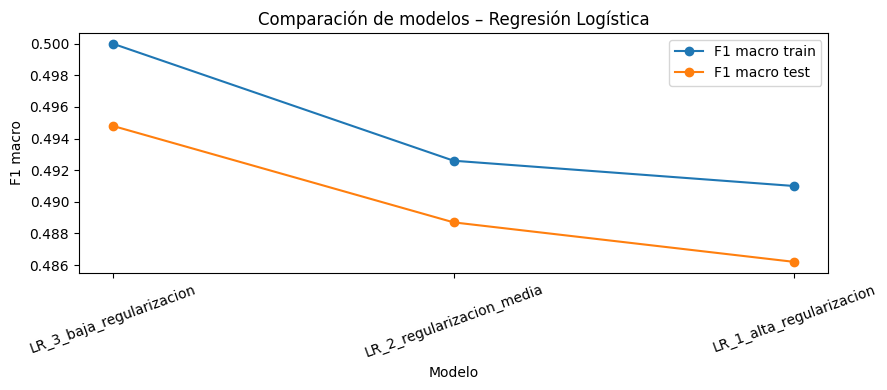


Modelo final seleccionado: LR_3_baja_regularizacion


,valor
modelo,LR_3_baja_regularizacion
accuracy_train,0.5105
accuracy_test,0.5062
balanced_accuracy_test,0.5027
f1_macro_train,0.5000
f1_macro_test,0.4948
gap_f1_train_test,0.0052
C,1.0000
max_iter,2000
class_weight,balanced


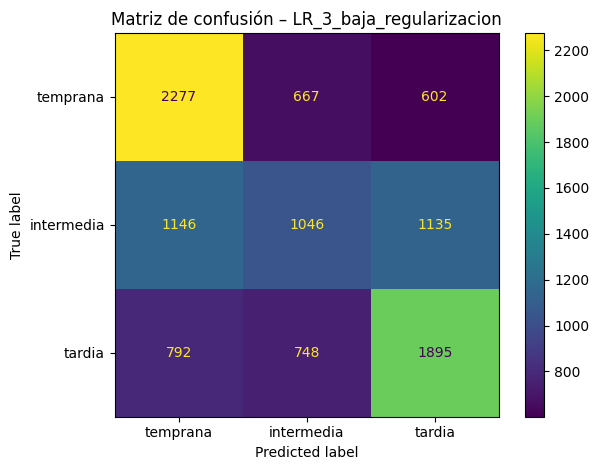


Reporte de clasificación – Regresión Logística:
              precision    recall  f1-score   support

    temprana       0.54      0.64      0.59      3546
  intermedia       0.43      0.31      0.36      3327
      tardia       0.52      0.55      0.54      3435

    accuracy                           0.51     10308
   macro avg       0.50      0.50      0.49     10308
weighted avg       0.50      0.51      0.50     10308



In [37]:
mejor_lr_nombre, modelo_lr_final, y_pred_lr = seleccionar_mejor(resultados_lr_df, modelos_lr_dict)
mostrar_resultados("Regresión Logística", mejor_lr_nombre, y_test, y_pred_lr, resultados_lr_df, "lr")

---
## 11. Comparación final entre los tres algoritmos

Se comparan los mejores modelos de cada algoritmo usando las mismas métricas.

,algoritmo,mejor_modelo,accuracy_test,balanced_accuracy_test,f1_macro_test,gap_f1_train_test
0,Random Forest,RF_3_mas_flexible,0.5147,0.5112,0.5025,0.0792
1,XGBoost,XGB_2_intermedio,0.5145,0.5108,0.5013,0.0904
2,Regresión Logística,LR_3_baja_regularizacion,0.5062,0.5027,0.4948,0.0052


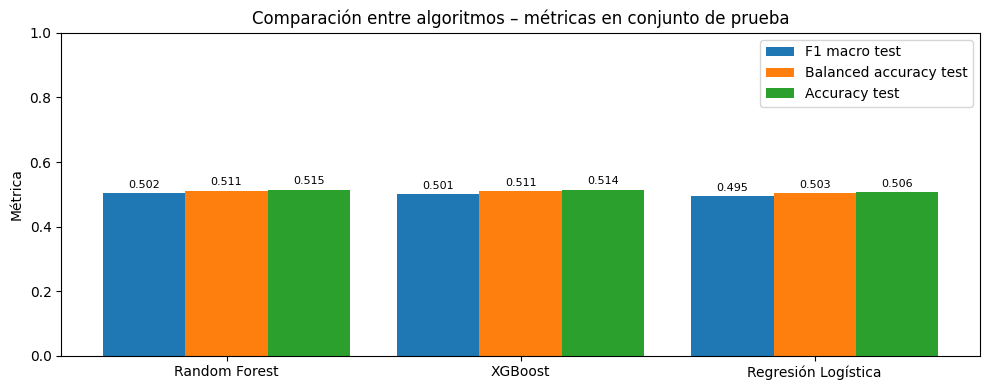


Mejor algoritmo: Random Forest (RF_3_mas_flexible) – F1 macro test = 0.5025


In [38]:
def fila_mejor_resumen(algoritmo, nombre, df):
    fila = df[df["modelo"] == nombre].iloc[0]
    return {
        "algoritmo": algoritmo,
        "mejor_modelo": nombre,
        "accuracy_test": fila["accuracy_test"],
        "balanced_accuracy_test": fila["balanced_accuracy_test"],
        "f1_macro_test": fila["f1_macro_test"],
        "gap_f1_train_test": fila["gap_f1_train_test"]
    }

comparacion = pd.DataFrame([
    fila_mejor_resumen("Random Forest",      mejor_rf_nombre,  resultados_rf_df),
    fila_mejor_resumen("XGBoost",            mejor_xgb_nombre, resultados_xgb_df),
    fila_mejor_resumen("Regresión Logística", mejor_lr_nombre, resultados_lr_df),
])

display(comparacion)
comparacion.to_csv("outputs/comparacion_algoritmos.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(comparacion))
width = 0.28

b1 = ax.bar([i - width for i in x], comparacion["f1_macro_test"],         width, label="F1 macro test")
b2 = ax.bar([i          for i in x], comparacion["balanced_accuracy_test"], width, label="Balanced accuracy test")
b3 = ax.bar([i + width for i in x], comparacion["accuracy_test"],          width, label="Accuracy test")

ax.set_xticks(list(x))
ax.set_xticklabels(comparacion["algoritmo"])
ax.set_ylabel("Métrica")
ax.set_title("Comparación entre algoritmos – métricas en conjunto de prueba")
ax.legend()
ax.set_ylim(0, 1)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("outputs/grafico_comparacion_algoritmos.png", dpi=300, bbox_inches="tight")
plt.show()

ganador = comparacion.sort_values("f1_macro_test", ascending=False).iloc[0]
print(f"\nMejor algoritmo: {ganador['algoritmo']} ({ganador['mejor_modelo']}) "
      f"– F1 macro test = {ganador['f1_macro_test']:.4f}")